# 🚦 Traffic Sign Detection — YOLOv8 Fine-Tuning
**Pipeline completa:** dataset → training → valutazione → export ONNX

**Classi target (9):** stop · parking · priority · roundabout · one_way · no_entry · exit_highway · entrance_highway · crosswalk

---
> **Prima di iniziare:** vai su `Runtime → Change runtime type → T4 GPU`


## ⚙️ Phase 0 — Setup environment

In [ ]:
# Install required dependencies for training, data handling and visualization
!pip install ultralytics roboflow opencv-python-headless matplotlib --quiet

import os, sys, random, shutil, csv, json
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Check GPU availability — T4 GPU recommended for training speed
import torch
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU: {gpu} ({vram:.1f} GB VRAM)")
else:
    print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU")

# Create project folder structure for images, labels and outputs
DIRS = [
    "dataset_traffic/images/train", "dataset_traffic/images/val", "dataset_traffic/images/test",
    "dataset_traffic/labels/train", "dataset_traffic/labels/val", "dataset_traffic/labels/test",
    "GTSDB", "roboflow_dataset_1", "roboflow_dataset_2", "roboflow_dataset_3", "roboflow_dataset_4",
    "roboflow_dataset_5", "runs", "test_images"
]
for d in DIRS:
    Path(d).mkdir(parents=True, exist_ok=True)

# Define the 14 target classes with their corresponding YOLO class IDs
LOCAL_CLASSES = {
    "stop": 0, "parking": 1, "priority": 2, "roundabout": 3,
    "one_way": 4, "no_entry": 5, "exit_highway": 6,
    "entrance_highway": 7, "crosswalk": 8, "pedestrian": 9,
    "car": 10, "trafficlight": 11, "stopline": 12,
    "roadblock": 13,
}
CLASS_NAMES = list(LOCAL_CLASSES.keys())

# Mount Google Drive to persist checkpoints across Colab sessions
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Setup complete!")
print("Target classes:", CLASS_NAMES)

⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Setup complete!
Target classes: ['stop', 'parking', 'priority', 'roundabout', 'one_way', 'no_entry', 'exit_highway', 'entrance_highway', 'crosswalk', 'pedestrian', 'car', 'trafficlight', 'stopline', 'roadblock']


## 📦 Phase 1 — Dataset Acquisition

**Strategy:**
- **GTSDB** → 5 classes: stop, priority, roundabout, no_entry, crosswalk
- **Roboflow** → 4 classes: parking, one_way, exit_highway, entrance_highway


Run 1a and 1b in order


### 1a — Download GTSDB

In [ ]:
import os, subprocess, csv, shutil
from pathlib import Path
from collections import Counter

# Set Kaggle API token as environment variable (replaces kaggle.json auth)
os.environ["KAGGLE_API_TOKEN"] = "KGAT_e6bc117608e2902e5dde1a6e3e422b13"

# Create GTSDB folder if it doesn't exist
Path("GTSDB").mkdir(exist_ok=True)

# Download the GTSDB training set (includes gt.txt with bounding box annotations)
print("Downloading GTSDB TrainSet...")
result = subprocess.run([
    "kaggle", "datasets", "download",
    "hieunguyen21/german-traffic-sign-detection-benchmark-gtsdb",
    "--path", "GTSDB/", "--unzip", "--quiet"
], capture_output=True, text=True, env=os.environ)

if result.returncode != 0:
    print(f"❌ {result.stderr}")
else:
    print("✅ Download complete")

# Flatten subfolder structure — move all .ppm images to GTSDB/ root
for ppm in Path("GTSDB").rglob("*.ppm"):
    dst = Path("GTSDB") / ppm.name
    if ppm.parent != Path("GTSDB"):
        shutil.move(str(ppm), str(dst))

# Move gt.txt to GTSDB/ root if it was extracted into a subfolder
for gt in Path("GTSDB").rglob("gt.txt"):
    dst = Path("GTSDB/gt.txt")
    if gt != dst:
        shutil.move(str(gt), str(dst))

# Verify download and print instance counts for our 5 target classes
ppm_files = list(Path("GTSDB").glob("*.ppm"))
gt_file   = Path("GTSDB/gt.txt")

# Mapping from original GTSDB class IDs to our local class IDs
GTSDB_MAP = {14:0, 12:2, 40:3, 17:5, 27:8, 28:8}
cls_names = {0:"stop", 2:"priority", 3:"roundabout", 5:"no_entry", 8:"crosswalk"}

if ppm_files and gt_file.exists():
    # Count bounding box annotations per class in gt.txt
    counts = Counter()
    with open(gt_file) as f:
        for row in csv.reader(f, delimiter=";"):
            if len(row) >= 6:
                try: counts[int(row[5])] += 1
                except ValueError: pass
    print(f"\n✅ GTSDB ready: {len(ppm_files)} images")
    print("   Classes of interest:")
    for gid, lid in GTSDB_MAP.items():
        if gid in counts:
            print(f"     {cls_names[lid]:<15} {counts[gid]:>4} instances")
else:
    # Debug: show what was actually downloaded if structure is wrong
    print(f"❌ ppm: {len(ppm_files)}, gt.txt: {gt_file.exists()}")
    print("   Found structure:")
    for p in sorted(Path("GTSDB").rglob("*"))[:20]:
        print(f"     {p}")

✅ Download complete

✅ GTSDB ready: 900 images
   Classes of interest:
     stop              32 instances
     priority          85 instances
     roundabout        10 instances
     no_entry          29 instances
     crosswalk          3 instances
     crosswalk         14 instances


In [ ]:
ROBOFLOW_API_KEY = "ed7UXDe5pRP51HaIfuzn"

# Each entry is one Roboflow dataset. Add/remove dicts freely.
ROBOFLOW_DATASETS = [
    {
        "name":      "Traffic Signs Detection Europe",   # human-readable label (for logs)
        "workspace": "radu-oprea-r4xnm",
        "project":   "traffic-signs-detection-europe",
        "version":   14,
        "location":  "roboflow_dataset_1",              # unique local folder
        "name_remap": {                                  # RF class name → your local class name
            "info_crosswalk":        "crosswalk",
            "info_one_way_traffic":  "one_way",
            "info_parking":          "parking",
            "info_highway":          "entrance_highway",
            "mand_roundabout":       "roundabout",
            "prio_stop":             "stop",
            "prio_priority_road":    "priority",
            "forb_ahead":            "no_entry",

        },
    },
    {
        "name":      "BFMC Kookmin University",   # human-readable label (for logs)
        "workspace": "kookmin-university-db0o8",
        "project":   "bfmc-rgid8",
        "version":   12,
        "location":  "roboflow_dataset_2",              # unique local folder
        "name_remap": {                                  # RF class name → your local class name
            "crosswalk-sign":        "crosswalk",
            "one-way-road-sign":  "one_way",
            "parking-sign":          "parking",
            "highway-entrance-sign":          "entrance_highway",
            "highway-exit-sign":       "exit_highway",
            "round-about-sign":       "roundabout",
            "stop-sign":             "stop",
            "priority-sign":    "priority",
            "no-entry-road-sign":            "no_entry",
            "obstacle-human":  "pedestrian",
            "obstacle-vehicle": "car"
        },
    },
    {
        "name":      "Team DriverLES",   # human-readable label (for logs)
        "workspace": "team-driverles",
        "project":   "bfmc-6btkg",
        "version":   16,
        "location":  "roboflow_dataset_3",              # unique local folder
        "name_remap": {                                  # RF class name → your local class name
            "crosswalk-sign":        "crosswalk",
            "one-way-road-sign":  "one_way",
            "parking-sign":          "parking",
            "highway-entry-sign":          "entrance_highway",
            "highway-exit-sign":       "exit_highway",
            "stop-sign":             "stop",
            "priority-sign":    "priority",
            "no-entry-road-sign":            "no_entry",
            "stop-line":    "stopline",
            "traffic-light":  "trafficlight",
            "closed-road-stand": "roadblock"
        },
    },
    {
        "name":      "PLeBFMC",   # human-readable label (for logs)
        "workspace": "plebfmc",
        "project":   "bfmc-ynwep",
        "version":   7,
        "location":  "roboflow_dataset_4",              # unique local folder
        "name_remap": {                                  # RF class name → your local class name
            "onewayroad":  "one_way",
            "highway_entry":          "entrance_highway",
            "highway_exit":       "exit_highway"
        },
    },
    {
        "name":      "The Newbies",   # human-readable label (for logs)
        "workspace": "the-newbies-ael9e",
        "project":   "bfmc-ynbzk",
        "version":   1,
        "location":  "roboflow_dataset_5",              # unique local folder
        "name_remap": {                                  # RF class name → your local class name
            "onewayroad":  "one_way",
            "highway_entry":          "entrance_highway",
            "highway_exit":       "exit_highway",
        },
    }
]
def download_roboflow_datasets():
    from roboflow import Roboflow
    import shutil
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)

    for ds in ROBOFLOW_DATASETS:
        yaml_path = Path(ds["location"]) / "data.yaml"

        # Skip download if the dataset folder already exists
        if yaml_path.exists():
            print(f"✅ '{ds['name']}' already present at '{ds['location']}' — skipping")
            continue

        print(f"⬇️  Downloading '{ds['name']}' → '{ds['location']}' ...")
        try:
            shutil.rmtree(ds["location"], ignore_errors=True)
            project = rf.workspace(ds["workspace"]).project(ds["project"])
            project.version(ds["version"]).download("yolov8", location=ds["location"])
            print(f"  ✅ Done")
        except Exception as e:
            print(f"  ❌ Failed: {e}")




### 1b — Download Roboflow

In [ ]:
# # Mapping from Roboflow class names → local class names
# # Covers both "Traffic Signs Detection Europe" (Radu Oprea, primary)
# # and "Traffic and Road Signs" (usmanchaudhry622, fallback)
# ROBOFLOW_API_KEY = "ed7UXDe5pRP51HaIfuzn"
# RF_NAME_REMAP = {
#     # Primary dataset: Traffic Signs Detection Europe (Radu Oprea)
#     "info_crosswalk":        "crosswalk",
#     "warn_crosswalk":        "crosswalk",
#     "info_one_way_traffic":  "one_way",
#     "info_parking":          "parking",
#     "info_highway":          "entrance_highway",
#     "mand_roundabout":       "roundabout",
#     "warn_roundabout":       "roundabout",
#     "prio_stop":             "stop",
#     "prio_priority_road":    "priority",
#     "forb_ahead":            "no_entry",
#     # Fallback dataset: Traffic and Road Signs (usmanchaudhry622)
#     "Crosswalk sign":        "crosswalk",
#     "One way road sign":     "one_way",
#     "Parking sign":          "parking",
#     "Highway entrance sign": "entrance_highway",
#     "Highway exit sign":     "exit_highway",
#     "Round-about sign":      "roundabout",
#     "Stop sign":             "stop",
#     "Priority sign":         "priority",
#     "No-entry road sign":    "no_entry",
# }

# # Check if dataset was already downloaded in a previous run
# rf_ok = (Path("roboflow_dataset") / "data.yaml").exists()

# if rf_ok:
#     print("✅ Roboflow dataset already present — skipping download")
# else:
#     from roboflow import Roboflow
#     rf = Roboflow(api_key=ROBOFLOW_API_KEY)
#     downloaded = False

#     # Try primary dataset first (Traffic Signs Detection Europe, version 14)
#     try:
#         project = rf.workspace("radu-oprea-r4xnm").project("traffic-signs-detection-europe")
#         project.version(14).download("yolov8", location="roboflow_dataset")
#         print("✅ Primary dataset downloaded")
#         downloaded = True
#     except Exception as e:
#         print(f"Primary dataset unavailable ({e}), trying fallback...")

#     # Fall back to alternative dataset if primary fails
#     if not downloaded:
#         try:
#             project = rf.workspace("usmanchaudhry622-gmail-com").project("traffic-and-road-signs")
#             project.version(1).download("yolov8", location="roboflow_dataset")
#             print("✅ Fallback dataset downloaded")
#         except Exception as e:
#             print(f"❌ Both datasets unavailable: {e}")

# # Read class names from the downloaded dataset's data.yaml
# yaml_path = Path("roboflow_dataset/data.yaml")
# if yaml_path.exists():
#     import yaml
#     with open(yaml_path) as f:
#         rf_data = yaml.safe_load(f)

#     # Support both list format and dict format for class names
#     rf_names = rf_data.get("names", [])
#     if isinstance(rf_names, list):
#         rf_id_to_name = {i: n for i, n in enumerate(rf_names)}
#     else:
#         rf_id_to_name = {int(k): v for k, v in rf_names.items()}

#     # Print all classes and show which ones match our 9 target classes
#     print(f"\nRoboflow dataset classes ({len(rf_id_to_name)} total):")
#     for i, name in sorted(rf_id_to_name.items()):
#         mapped = RF_NAME_REMAP.get(name, "—")
#         mark   = "✅" if mapped != "—" else "  "
#         print(f"  {mark} [{i:2d}] {name:<35} → {mapped}")

#     # Build numeric ID → local ID mapping used during dataset preparation
#     RF_ID_REMAP = {}
#     for rf_id, rf_name in rf_id_to_name.items():
#         local = RF_NAME_REMAP.get(rf_name)
#         if local and local in LOCAL_CLASSES:
#             RF_ID_REMAP[rf_id] = LOCAL_CLASSES[local]

#     print(f"\n✅ {len(RF_ID_REMAP)} classes mapped out of 9 targets")
#     if len(RF_ID_REMAP) < 7:
#         print("⚠️  Fewer than 7 classes mapped — check class names above match RF_NAME_REMAP")

### 1c — Merge, remap e split dataset

In [ ]:
!pip install roboflow
from PIL import Image

# Split ratios for train / validation / test sets
SPLIT_RATIOS = {"train": 0.80, "val": 0.15, "test": 0.05}
RANDOM_SEED  = 42
OUTPUT_DIR   = Path("dataset_traffic")

# ── Load samples from GTSDB ──────────────────────────────────────────────────
def load_gtsdb():
    gt_file = Path("GTSDB/gt.txt")
    if not gt_file.exists():
        print("⚠️  GTSDB/gt.txt not found — skipping")
        return {}

    # Each key is a unique image identifier, value holds labels and image path
    samples = defaultdict(lambda: {"labels": [], "img_src": None})

    with open(gt_file) as f:
        for row in csv.reader(f, delimiter=";"):
            if len(row) < 6:
                continue
            try:
                img_name = row[0].strip()
                x1, y1, x2, y2 = int(row[1]), int(row[2]), int(row[3]), int(row[4])
                cls_id = int(row[5])
            except (ValueError, IndexError):
                continue

            # Skip classes that are not in our 9 target classes
            if cls_id not in GTSDB_MAP:
                continue

            # Try to find the image file with common extensions
            img_path = None
            for ext in [".ppm", ".jpg", ".png"]:
                c = Path("GTSDB") / Path(img_name).with_suffix(ext).name
                if c.exists():
                    img_path = c
                    break
            if img_path is None:
                c = Path("GTSDB") / img_name
                if c.exists():
                    img_path = c
            if img_path is None:
                continue

            # Get image dimensions to normalize bounding box coordinates
            try:
                W, H = Image.open(img_path).size
            except Exception:
                W, H = 1360, 800  # GTSDB default resolution as fallback

            # Convert pixel coordinates to YOLO format (cx, cy, w, h) normalized [0, 1]
            cx = max(0.0, min(1.0, ((x1 + x2) / 2) / W))
            cy = max(0.0, min(1.0, ((y1 + y2) / 2) / H))
            bw = max(0.001, min(1.0, (x2 - x1) / W))
            bh = max(0.001, min(1.0, (y2 - y1) / H))

            local_cls = GTSDB_MAP[cls_id]
            key = f"gtsdb_{img_path.stem}"
            samples[key]["img_src"] = img_path
            samples[key]["labels"].append(f"{local_cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    # Keep only samples that have a valid image path
    result = {k: v for k, v in samples.items() if v["img_src"]}
    print(f"  GTSDB: {len(result)} useful images")
    return result

# ── Load samples from Roboflow dataset ───────────────────────────────────────
# def load_roboflow():
#     if not Path("roboflow_dataset/data.yaml").exists():
#         print("⚠️  Roboflow dataset not found — skipping")
#         return {}

#     # Rebuild RF_ID_REMAP from data.yaml if it was not set in a previous cell
#     try:
#         id_remap = RF_ID_REMAP
#     except NameError:
#         import yaml
#         with open("roboflow_dataset/data.yaml") as f:
#             rf_data = yaml.safe_load(f)
#         rf_names = rf_data.get("names", [])
#         if isinstance(rf_names, list):
#             rf_id_to_name = {i: n for i, n in enumerate(rf_names)}
#         else:
#             rf_id_to_name = {int(k): v for k, v in rf_names.items()}
#         id_remap = {}
#         for rf_id, rf_name in rf_id_to_name.items():
#             local = RF_NAME_REMAP.get(rf_name)
#             if local and local in LOCAL_CLASSES:
#                 id_remap[rf_id] = LOCAL_CLASSES[local]

#     samples = {}
#     for split in ["train", "valid", "test"]:
#         img_dir = Path("roboflow_dataset") / split / "images"
#         lbl_dir = Path("roboflow_dataset") / split / "labels"
#         if not img_dir.exists():
#             continue
#         for img_path in list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")):
#             lbl_path = lbl_dir / img_path.with_suffix(".txt").name
#             if not lbl_path.exists():
#                 continue
#             new_labels = []
#             for line in lbl_path.read_text().strip().splitlines():
#                 parts = line.strip().split()
#                 if len(parts) != 5:
#                     continue
#                 try:
#                     old_cls = int(parts[0])
#                     vals = [float(p) for p in parts[1:]]
#                 except ValueError:
#                     continue
#                 # Skip classes outside our target set or with invalid bbox values
#                 if old_cls not in id_remap or any(v < 0 or v > 1 for v in vals):
#                     continue
#                 # Remap Roboflow class ID to our local class ID
#                 new_labels.append(f"{id_remap[old_cls]} {' '.join(parts[1:])}")
#             if new_labels:
#                 key = f"rf_{split}_{img_path.stem}"
#                 samples[key] = {"img_src": img_path, "labels": new_labels}

#     print(f"  Roboflow: {len(samples)} useful images")
#     return samples


def load_roboflow():
    """
    Iterates over every dataset in ROBOFLOW_DATASETS.
    For each one it:
      1. Reads data.yaml to get the RF id→name mapping
      2. Applies the dataset-specific name_remap to translate to local class IDs
      3. Walks train/valid/test splits and collects valid (image, labels) pairs
    All results are merged into a single dict keyed by a unique string that
    encodes the dataset index, split, and image stem — so there are no collisions.
    """
    import yaml

    all_samples = {}

    for ds_idx, ds in enumerate(ROBOFLOW_DATASETS):
        location  = Path(ds["location"])
        yaml_path = location / "data.yaml"

        if not yaml_path.exists():
            print(f"  ⚠️  '{ds['name']}' not found at '{location}' — skipping")
            continue

        # ── Build RF id → local class id mapping for this dataset ────────────
        with open(yaml_path) as f:
            rf_data = yaml.safe_load(f)

        rf_names = rf_data.get("names", [])
        rf_id_to_name = (
            {i: n for i, n in enumerate(rf_names)}
            if isinstance(rf_names, list)
            else {int(k): v for k, v in rf_names.items()}
        )

        id_remap = {}
        for rf_id, rf_name in rf_id_to_name.items():
            local = ds["name_remap"].get(rf_name)
            if local and local in LOCAL_CLASSES:
                id_remap[rf_id] = LOCAL_CLASSES[local]

        # ── Walk every split folder ───────────────────────────────────────────
        ds_count = 0
        for split in ["train", "valid", "test"]:
            img_dir = location / split / "images"
            lbl_dir = location / split / "labels"
            if not img_dir.exists():
                continue

            for img_path in list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")):
                lbl_path = lbl_dir / img_path.with_suffix(".txt").name
                if not lbl_path.exists():
                    continue

                new_labels = []
                for line in lbl_path.read_text().strip().splitlines():
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    try:
                        old_cls = int(parts[0])
                        vals    = [float(p) for p in parts[1:]]
                    except ValueError:
                        continue
                    if old_cls not in id_remap or any(v < 0 or v > 1 for v in vals):
                        continue
                    new_labels.append(f"{id_remap[old_cls]} {' '.join(parts[1:])}")

                if new_labels:
                    # Key encodes dataset index + split + stem → guaranteed unique
                    key = f"rf{ds_idx}_{split}_{img_path.stem}"
                    all_samples[key] = {"img_src": img_path, "labels": new_labels}
                    ds_count += 1

        print(f"  Roboflow '{ds['name']}': {ds_count} useful images")

    print(f"  Roboflow total: {len(all_samples)} images across {len(ROBOFLOW_DATASETS)} datasets")
    return all_samples


# ── Shuffle, split and save the unified dataset to disk ──────────────────────
def save_dataset(all_samples):
    keys = list(all_samples.keys())
    random.seed(RANDOM_SEED)
    random.shuffle(keys)
    n       = len(keys)
    n_train = int(n * SPLIT_RATIOS["train"])
    n_val   = int(n * SPLIT_RATIOS["val"])
    splits  = {
        "train": keys[:n_train],
        "val":   keys[n_train:n_train+n_val],
        "test":  keys[n_train+n_val:],
    }
    for split, split_keys in splits.items():
        for i, key in enumerate(split_keys):
            s    = all_samples[key]
            src  = Path(s["img_src"])
            # Add index suffix to avoid filename collisions across datasets
            stem = f"{src.stem}_{i:05d}"
            dst_img = OUTPUT_DIR / "images" / split / f"{stem}.jpg"
            dst_lbl = OUTPUT_DIR / "labels" / split / f"{stem}.txt"
            try:
                # Convert PPM (GTSDB format) to JPG, copy directly otherwise
                if src.suffix.lower() == ".ppm":
                    Image.open(src).convert("RGB").save(dst_img, quality=92)
                else:
                    shutil.copy(src, dst_img)
            except Exception as e:
                continue
            dst_lbl.write_text("\n".join(s["labels"]) + "\n")
        print(f"  Split '{split}': {len(split_keys)} samples saved")
    return splits

# ── Write data.yaml required by Ultralytics YOLOv8 ───────────────────────────
def write_yaml():
    names_str = "\n".join(f"  {i}: {n}" for i, n in enumerate(CLASS_NAMES))
    yaml_txt  = f"path: {OUTPUT_DIR.resolve()}\ntrain: images/train\nval:   images/val\ntest:  images/test\n\nnc: {len(CLASS_NAMES)}\nnames:\n{names_str}\n"
    (OUTPUT_DIR / "data.yaml").write_text(yaml_txt)
    return str((OUTPUT_DIR / "data.yaml").resolve())

# ── Run the full pipeline ─────────────────────────────────────────────────────
# print("Loading datasets...")
# gtsdb_samples = load_gtsdb()
# rf_samples    = load_roboflow()

# # Merge both sources, appending "_rf" suffix to avoid key collisions
# all_samples = {}
# all_samples.update(gtsdb_samples)
# for k, v in rf_samples.items():
#     all_samples[k if k not in all_samples else k + "_rf"] = v

# print(f"  Total: {len(all_samples)} samples")

# print("\nSaving splits...")
# splits    = save_dataset(all_samples)
# YAML_PATH = write_yaml()
# print(f"\n✅ Dataset ready! data.yaml → {YAML_PATH}")

download_roboflow_datasets()

print("Loading datasets...")
gtsdb_samples = load_gtsdb()          # unchanged from your original
rf_samples    = load_roboflow()       # now loads ALL configured datasets

all_samples = {}
all_samples.update(gtsdb_samples)
for k, v in rf_samples.items():
    all_samples[k if k not in all_samples else k + "_x"] = v

print(f"  Total: {len(all_samples)} samples")

print("\nSaving splits...")
splits    = save_dataset(all_samples)
YAML_PATH = write_yaml()
print(f"\n✅ Dataset ready! data.yaml → {YAML_PATH}")

✅ 'Traffic Signs Detection Europe' already present at 'roboflow_dataset_1' — skipping
✅ 'BFMC Kookmin University' already present at 'roboflow_dataset_2' — skipping
✅ 'Team DriverLES' already present at 'roboflow_dataset_3' — skipping
✅ 'PLeBFMC' already present at 'roboflow_dataset_4' — skipping
✅ 'The Newbies' already present at 'roboflow_dataset_5' — skipping
Loading datasets...
  GTSDB: 149 useful images
  Roboflow 'Traffic Signs Detection Europe': 1752 useful images
  Roboflow 'BFMC Kookmin University': 7502 useful images
  Roboflow 'Team DriverLES': 2220 useful images
  Roboflow 'PLeBFMC': 1466 useful images
  Roboflow 'The Newbies': 2864 useful images
  Roboflow total: 15804 images across 5 datasets
  Total: 15953 samples

Saving splits...
  Split 'train': 12762 samples saved
  Split 'val': 2392 samples saved
  Split 'test': 799 samples saved

✅ Dataset ready! data.yaml → /content/dataset_traffic/data.yaml


## 🔍 Phase 2 — Verify dataset

In [ ]:
# RGB colors assigned to each class for bounding box visualization
CLASS_COLORS_RGB = [
    (220,  50,  50),   # stop
    (220, 150,   0),   # parking
    (  0, 180,   0),   # priority
    (180,   0, 180),   # roundabout
    (  0, 190, 190),   # one_way
    (150,  30,  30),   # no_entry
    (160,  90,   0),   # exit_highway
    (  0, 120, 220),   # entrance_highway
    ( 50, 200,  50),   # crosswalk
    ( 90,  90,  90),   # pedestrian
    ( 90,  185,  90),   # car
    ( 107,  90,  90),   # trafficlight
    ( 90,  90,  200),   # stopline
    ( 90,  200,  90),   # roadblock
]

def count_classes(split):
    """Count bounding box instances per class in a given split folder."""
    counts  = Counter()
    lbl_dir = OUTPUT_DIR / "labels" / split
    if not lbl_dir.exists():
        return counts
    for lbl in lbl_dir.glob("*.txt"):
        for line in lbl.read_text().strip().splitlines():
            parts = line.strip().split()
            # Each valid YOLO label line has exactly 5 fields: cls cx cy w h
            if len(parts) == 5:
                try:
                    counts[int(parts[0])] += 1
                except ValueError:
                    pass
    return counts

# Print per-class instance counts across all three splits
print(f"{'Class':<22} {'train':>8} {'val':>8} {'test':>8}  status")
print("─" * 60)

all_ok = True
for cls_id, cls_name in enumerate(CLASS_NAMES):
    # Count instances for this class in each split
    row = {sp: count_classes(sp).get(cls_id, 0) for sp in ["train", "val", "test"]}

    # Flag classes with too few samples — minimum thresholds: 50 train, 15 val
    if row["train"] >= 50 and row["val"] >= 15:
        status = "✅"
    elif row["train"] > 0:
        status = "⚠️ "
    else:
        status = "❌ MISSING"

    if row["train"] < 50:
        all_ok = False

    print(f"{cls_name:<22} {row['train']:>8} {row['val']:>8} {row['test']:>8}  {status}")

print()
if all_ok:
    print("✅ All classes have sufficient instances")
else:
    print("⚠️  Some classes have too few instances — model will have low recall on those classes")

Class                     train      val     test  status
────────────────────────────────────────────────────────────
stop                       1116      225       57  ✅
parking                     459       85       39  ✅
priority                    907      166       59  ✅
roundabout                  743      127       43  ✅
one_way                    2107      376      140  ✅
no_entry                    817      147       49  ✅
exit_highway               1934      382      115  ✅
entrance_highway           2214      396      138  ✅
crosswalk                  1591      315      100  ✅
pedestrian                  569       97       41  ✅
car                         553      117       34  ✅
trafficlight                 58       13        2  ⚠️ 
stopline                    940      196       58  ✅
roadblock                   204       36       11  ✅

✅ All classes have sufficient instances


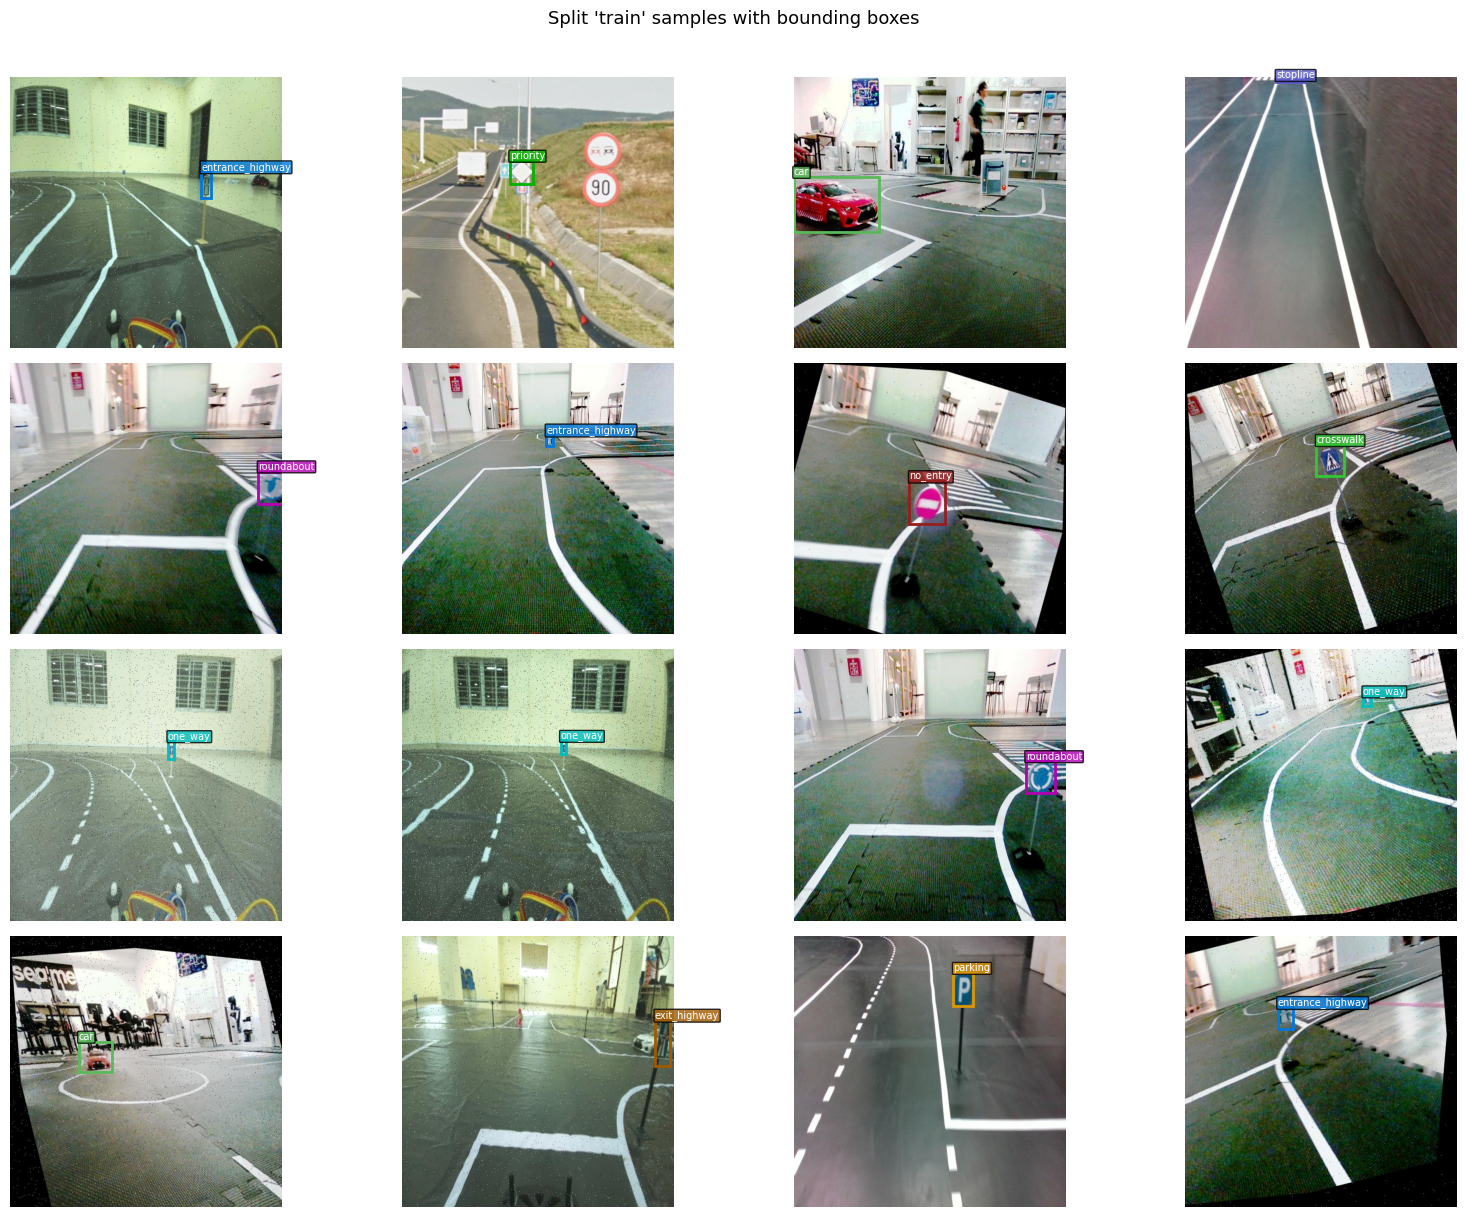

✅ Grid saved to dataset_traffic/check_train.jpg


In [ ]:
# Visualize a random grid of samples with their bounding boxes drawn on top
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

def show_samples(split="train", n=16, seed=42):
    """
    Display a grid of n random images from the given split,
    with color-coded bounding boxes and class labels overlaid.
    Also saves the grid as a JPG file for later inspection.
    """
    img_dir = OUTPUT_DIR / "images" / split
    lbl_dir = OUTPUT_DIR / "labels" / split
    imgs    = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    if not imgs:
        print(f"No images found in {img_dir}")
        return

    # Randomly sample n images with a fixed seed for reproducibility
    random.seed(seed)
    selected = random.sample(imgs, min(n, len(imgs)))

    # Build a 4-column grid layout
    cols = 4
    rows = (len(selected) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    # Hide all axes by default — only used cells will show content
    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, selected):
        from PIL import Image as PILImage
        img  = PILImage.open(img_path).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        ax.axis("off")

        # Load the corresponding label file if it exists
        lbl_path = lbl_dir / img_path.with_suffix(".txt").name
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                except ValueError:
                    continue

                # Convert YOLO normalized coords back to pixel coordinates
                x1 = (cx - bw / 2) * W
                y1 = (cy - bh / 2) * H
                w  = bw * W
                h  = bh * H

                # Draw bounding box with the class color
                color = [c/255 for c in CLASS_COLORS_RGB[cls_id % len(CLASS_COLORS_RGB)]]
                rect  = patches.Rectangle((x1, y1), w, h, linewidth=2,
                                          edgecolor=color, facecolor="none")
                ax.add_patch(rect)

                # Add class name label above the bounding box
                ax.text(x1, y1 - 4, CLASS_NAMES[cls_id],
                        fontsize=7, color="white",
                        bbox=dict(boxstyle="round,pad=0.1", facecolor=color, alpha=0.8))

    fig.suptitle(f"Split '{split}' samples with bounding boxes", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f"dataset_traffic/check_{split}.jpg", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"✅ Grid saved to dataset_traffic/check_{split}.jpg")

# Run visualization on the training split
show_samples("train", n=16)

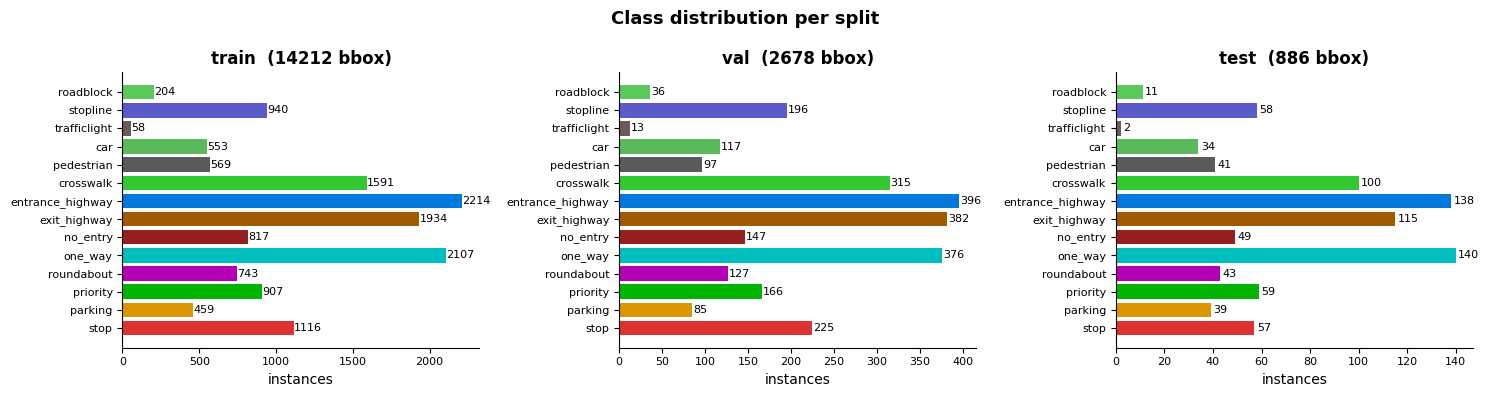

✅ Class distribution OK


In [ ]:
# Plot class distribution as horizontal bar charts for each split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "val", "test"]):
    # Get instance count per class for this split
    counts = count_classes(split)
    vals   = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]

    # Convert RGB tuples from 0-255 to 0-1 range for matplotlib
    colors = [[c/255 for c in CLASS_COLORS_RGB[i]] for i in range(len(CLASS_NAMES))]

    # Draw horizontal bars and annotate each with its count
    bars = ax.barh(CLASS_NAMES, vals, color=colors, edgecolor="none")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(v), va="center", fontsize=8)

    ax.set_title(f"{split}  ({sum(vals)} bbox)", fontweight="bold")
    ax.set_xlabel("instances")
    ax.tick_params(labelsize=8)
    # Remove top and right spines for a cleaner look
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Class distribution per split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("dataset_traffic/class_distribution.jpg", dpi=100, bbox_inches="tight")
plt.show()
print("✅ Class distribution OK")

## 🏋️ Phase 3 — Fine-tuning YOLOv8n

**Parametri chiave:**
- `freeze=10` → creezes the backbone, only the detection head is updated (transfer learning)
- `fliplr=0.0` → no horizontal flip (traffic signs are not symmetric)
- `patience=15` → utomatic early stopping if val loss does not improve

Training prints loss and metrics every epoch. Watch `mAP50` climbing towards 0.80+.

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

MODEL_SIZE = "yolov8n.pt"   # nano: fast on T4, ideal for OAK edge deployment
                             # switch to yolov8s.pt for higher accuracy (slower)
EPOCHS     = 80
BATCH      = 16             # reduce to 8 if you get CUDA out of memory errors
IMGSZ      = 640
FREEZE     = 10             # number of backbone layers to freeze during transfer learning
PROJECT    = "/content/drive/MyDrive/yolo_runs"   # ⬅️ checkpoints saved on Google Drive
RUN_NAME   = "traffic_9classes"
SAVE_PERIOD = 10            # save a checkpoint every N epochs (epoch10.pt, epoch20.pt, ...)

# Make sure the Drive folder exists
Path(PROJECT).mkdir(parents=True, exist_ok=True)

# ── Resume logic ─────────────────────────────────────────────────────────────
# If a previous run was interrupted, "last.pt" on Drive contains the most recent
# weights plus the optimizer state, so we can resume training from exactly where
# we left off — even after the Colab VM was disconnected.
last_ckpt = Path(f"{PROJECT}/{RUN_NAME}/weights/last.pt")
resume_training = last_ckpt.exists()

if resume_training:
    print(f"🔁 Resuming training from: {last_ckpt}")
    model = YOLO(str(last_ckpt))
else:
    print(f"🆕 Starting new training from pretrained weights: {MODEL_SIZE}")
    model = YOLO(MODEL_SIZE)

# When resuming, Ultralytics reuses ALL training args saved in last.pt,
# so we only pass resume=True. Otherwise we pass the full config.
if resume_training:
    results = model.train(resume=True, device="cpu")
else:
    results = model.train(
        data          = YAML_PATH,
        epochs        = EPOCHS,
        imgsz         = IMGSZ,
        batch         = BATCH,
        lr0           = 0.005,      # initial learning rate
        lrf           = 0.01,       # final learning rate (cosine decay factor)
        warmup_epochs = 5,          # gradually ramp up lr for the first 5 epochs
        optimizer     = "AdamW",
        patience      = 15,         # stop training if val loss stalls for 15 epochs
        freeze        = FREEZE,
        save_period   = SAVE_PERIOD,  # ⬅️ save a checkpoint every 10 epochs

        # Augmentation tuned for traffic signs
        hsv_h      = 0.02,
        hsv_s      = 0.5,
        hsv_v      = 0.4,
        degrees    = 5,
        translate  = 0.1,
        scale      = 0.4,
        flipud     = 0.0,
        fliplr     = 0.0,
        mosaic     = 0.8,
        copy_paste = 0.1,

        project    = PROJECT,
        name       = RUN_NAME,
        exist_ok   = True,          # reuse the same run folder across sessions
        device     = 0 if torch.cuda.is_available() else "cpu",
        verbose    = True,
    )

BEST_WEIGHTS = f"{PROJECT}/{RUN_NAME}/weights/best.pt"
print(f"\n✅ Training complete!")
print(f"   Best weights saved at: {BEST_WEIGHTS}")
print(f"   Periodic checkpoints:  {PROJECT}/{RUN_NAME}/weights/epoch*.pt")

In [ ]:
# ── Grafico loss e metriche durante il training ──────────────────────────────
import pandas as pd

results_csv = Path(f"{PROJECT}/{RUN_NAME}/results.csv")
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    metrics = [
        ("train/box_loss",  "Box Loss (train)",     "coral"),
        ("train/cls_loss",  "Cls Loss (train)",     "steelblue"),
        ("val/box_loss",    "Box Loss (val)",        "tomato"),
        ("val/cls_loss",    "Cls Loss (val)",        "royalblue"),
        ("metrics/mAP50",  "mAP@50",               "mediumseagreen"),
        ("metrics/mAP50-95","mAP@50-95",            "darkorchid"),
    ]

    for ax, (col, title, color) in zip(axes.flatten(), metrics):
        if col in df.columns:
            ax.plot(df["epoch"] if "epoch" in df.columns else range(len(df)),
                    df[col], color=color, linewidth=2)
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Epoca")
            ax.spines[["top","right"]].set_visible(False)
            ax.grid(alpha=0.3)

    plt.suptitle("Curve di training", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("training_curves.jpg", dpi=100, bbox_inches="tight")
    plt.show()
    print("✅ Curve di training salvate in training_curves.jpg")


## 📊 Phase 4 — Evaluation

**Target:** mAP50 ≥ 0.80 son all the classes.

Analyze the confusion matrix to see which classes are confused with one another.


In [ ]:
#BEST_WEIGHTS = f"runs/detect/runs/traffic_9classes/weights/best.pt"
BEST_WEIGHTS = f"{PROJECT}/{RUN_NAME}/weights/best.pt"

model_best = YOLO(BEST_WEIGHTS)

# Evaluate on the test split
metrics = model_best.val(
    data      = YAML_PATH,
    split     = "test",
    imgsz     = IMGSZ,
    conf      = 0.4,
    iou       = 0.5,
    plots     = True,
    save_json = True,
)

print("\n" + "─"*50)
print(f"  mAP50:       {metrics.box.map50:.3f}   (target ≥ 0.80)")
print(f"  mAP50-95:    {metrics.box.map:.3f}")
print(f"  Precision:   {metrics.box.mp:.3f}")
print(f"  Recall:      {metrics.box.mr:.3f}")
print("─"*50)

# Per-class metrics — use names returned by Ultralytics to avoid index mismatch
print("\nPer-class metrics:")
print(f"  {'Class':<22} {'AP50':>8} {'Prec':>8} {'Recall':>8}  status")
print("  " + "─"*52)

# metrics.box.ap_class_index contains the actual class IDs that appeared in the test set
for idx, cls_id in enumerate(metrics.box.ap_class_index):
    ap = metrics.box.ap50[idx]
    p  = metrics.box.p[idx]
    r  = metrics.box.r[idx]
    name   = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"cls_{cls_id}"
    status = "✅" if ap >= 0.75 else ("⚠️ " if ap >= 0.50 else "❌")
    print(f"  {status} {name:<20} {ap:>8.3f} {p:>8.3f} {r:>8.3f}")

# Warn about classes completely absent from test set
present = set(metrics.box.ap_class_index.tolist())
for cls_id, cls_name in enumerate(CLASS_NAMES):
    if cls_id not in present:
        print(f"  ⚠️  {cls_name:<20} — not present in test set (too few samples)")

# Show confusion matrix
from IPython.display import Image as IPImage, display
cm_path = Path(f"runs/detect/val/confusion_matrix_normalized.png")
if cm_path.exists():
    display(IPImage(str(cm_path), width=700))

In [ ]:
# ── Test inference on random samples of the test set ──────────────────────────
test_imgs = list((OUTPUT_DIR / "images" / "test").glob("*.jpg"))
random.seed(2)
sample_imgs = random.sample(test_imgs, min(8, len(test_imgs)))

results_inf = model_best.predict(
    source = [str(p) for p in sample_imgs],
    conf   = 0.4,
    iou    = 0.5,
    imgsz  = IMGSZ,
    verbose = False,
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax in axes:
    ax.axis("off")

for ax, result in zip(axes, results_inf):
    img_plot = result.plot(conf=True, labels=True)
    ax.imshow(img_plot[:, :, ::-1])   # BGR → RGB

plt.suptitle("Inference on test set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("inference_samples.jpg", dpi=100, bbox_inches="tight")
plt.show()
print("✅ Samples of inference saved in inference_samples.jpg")


## 📤 Phase 5 — Export ONNX

Export the model in ONNX format, ready for subsequent conversion to `.blob` for the Luxonis OAK camera.


In [ ]:
model_best = YOLO(BEST_WEIGHTS)

# Export ONNX
export_path = model_best.export(
    format   = "onnx",
    imgsz    = IMGSZ,
    opset    = 12,
    simplify = True,
    dynamic  = False,
)

print(f"✅ Modello esportato: {export_path}")

# Verify file dimension
onnx_path = Path(export_path)
size_mb   = onnx_path.stat().st_size / 1e6
print(f"   Dimensione: {size_mb:.1f} MB")
print(f"   Input: {IMGSZ}x{IMGSZ} RGB")
print(f"   Classi: {CLASS_NAMES}")

# Download on Google Drive
try:
    from google.colab import drive
    print("\nVuoi salvare su Google Drive? Esegui:")
    print("  drive.mount('/content/drive')")
    print(f"  !cp {export_path} /content/drive/MyDrive/")
except ImportError:
    pass

# Download from Colab
try:
    from google.colab import files
    files.download(BEST_WEIGHTS)          # weights PyTorch
    files.download(str(export_path))      # model ONNX
    print("\n✅ Download avviato per best.pt e best.onnx")
except Exception:
    print(f"\nFile pronti in:")
    print(f"  Pesi PT:   {BEST_WEIGHTS}")
    print(f"  Modello ONNX: {export_path}")


---
## ✅ Pipeline completed!

| File | Utility |
|------|-----|
| `runs/traffic_9classes/weights/best.pt` | Resume training or future fine-tuning |
| `best.onnx` | Convert to `.blob` for Luxonis OAK |

### Next step — Deploy on Luxonis OAK
```bash
# Install Luxonis tools
pip install modelconv

# Convert ONNX → blob for OAK (RVC2)
tools best.pt --imgsz "640 640" --use-rvc2
```

### Fine-tuning with OAK frame
```python
model = YOLO("runs/traffic_9classes/weights/best.pt")  # Starts from the previously loaded model
model.train(data="dataset_oak_frames/data.yaml", epochs=30, lr0=0.0005, freeze=20)
```
